In [6]:

import os
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score


# 1) Load + preprocess

path = "Merged_1.csv"
df = pd.read_csv(path)

# keep consistent column names
df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')
df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'individualism': 'Individualism',
    'masculinity': 'Masculinity',
    'powerdistance': 'Power Distance',
    'uncertaintyavoidance': 'Uncertainty Avoidance',
    'longtermorientation': 'Long Term Orientation',
    'democracyindex2021': 'Democracy Index',
    'indulgence': 'Indulgence',
    'gdp_per_capita': 'GDP (per capita)',
    'aged_65_older': 'Aged 65 Older',
    'stringency_index': 'Stringency Index',
    'population': 'Population'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()

# fixed features only (culture)
fixed_features = [
    'Individualism','Masculinity','Power Distance','Indulgence',
    'Uncertainty Avoidance','Long Term Orientation'
]    #,'Population',
    

# scale fixed features globally
df[fixed_features] = StandardScaler().fit_transform(df[fixed_features])

# ---- target: normalized cumulative deaths ----
df['TotalDeaths'] = df['TotalDeaths'].fillna(0)
daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()
df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)

# -----------------------
# 2) Dataset
# -----------------------
class CountryFixedDataset(Dataset):
    """
    Each country: predicts cumulative deaths sequence using only fixed features
    """
    def __init__(self, df, enc_len=100):
        self.enc_len = enc_len
        self.groups = []
        for country, g in df.groupby('Country'):
            g = g.sort_values('time_step').reset_index(drop=True)
            if len(g) >= enc_len:
                self.groups.append((country, g))
        self.fixed_cols = fixed_features
        self.target_col = 'cumulative_norm'

    def __len__(self):
        return len(self.groups)

    def __getitem__(self, idx):
        country, g = self.groups[idx]
        x_fixed = g[self.fixed_cols].iloc[0].values.astype(np.float32)
        y = g[self.target_col].iloc[:self.enc_len].values.astype(np.float32)
        return torch.tensor(x_fixed), torch.tensor(y), country

# -----------------------
# 3) Model (Fixed-only MLP)
# -----------------------
class FixedMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, seq_len):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, seq_len)

    def forward(self, x_fixed):
        h = F.relu(self.fc1(x_fixed))
        h = F.relu(self.fc2(h))
        y = self.out(h)
        return torch.sigmoid(y)   # [B, seq_len], normalized deaths ∈ [0,1]

# -----------------------
# 4) Train
# -----------------------
def train_model(model, loader, epochs=2000, lr=1e-3, clip=1.0, verbose_every=100):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    best = float('inf'); best_state = copy.deepcopy(model.state_dict())

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        for x_fixed, y, _ in loader:
            opt.zero_grad()
            pred = model(x_fixed)
            loss = loss_fn(pred, y)
            loss.backward()
            if clip:
                nn.utils.clip_grad_norm_(model.parameters(), clip)
            opt.step()
            total += loss.item() * x_fixed.size(0)
        epoch_loss = total / len(loader.dataset)
        if epoch_loss < best:
            best = epoch_loss
            best_state = copy.deepcopy(model.state_dict())
        if ep % verbose_every == 0 or ep == 1 or ep == epochs:
            print(f"Epoch {ep} — Loss: {epoch_loss:.6f} (best {best:.6f})")

    model.load_state_dict(best_state)
    print(f"\nBest training loss: {best:.6f}")
    return model

# -----------------------,'Population',
    'GDP (per capita)','Aged 65 Older','Democracy Index'
# 5) Run training
# -----------------------
ENC_LEN = 100
BATCH_SIZE = 78
EPOCHS = 2000
LR = 1e-2

dataset = CountryFixedDataset(df, enc_len=ENC_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model = FixedMLP(
    input_dim=len(fixed_features),
    hidden_dim=128,
    seq_len=ENC_LEN
)

model = train_model(model, loader, epochs=EPOCHS, lr=LR, clip=1.0, verbose_every=100)

# -----------------------
# 6) Evaluate one country
# -----------------------
country_name = "Bulgaria"  # <-- change here
g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
x_fixed = torch.tensor(g[fixed_features].iloc[0].values.astype(np.float32)).unsqueeze(0)         #unslabel='Train/Forecast split'queeze(0)
true_seq = g['cumulative_norm'].iloc[:ENC_LEN].values

with torch.no_grad():
    pred_seq = model(x_fixed).squeeze(0).cpu().numpy()

# plot
"""
plt.figure(figsize=(12,4.8))
plt.plot(true_seq, 'o-', label="True Cumulative", color='C0')
plt.plot(pred_seq, 'x--', label="Predicted Cumulative", color='red')
plt.title(f"Fixed-only model prediction — {country_name}")
plt.xlabel("Day")
plt.ylabel("Normalized cumulative deaths")
plt.legend(); plt.grid(True); plt.show()

# metrics
mse = mean_squared_error(true_seq, pred_seq)
r2 = r2_score(true_seq, pred_seq)
print(f"{country_name} — MSE: {mse:.4f}, R²: {r2:.4f}")
"""

Epoch 1 — Loss: 0.165385 (best 0.165385)
Epoch 100 — Loss: 0.002400 (best 0.002400)
Epoch 200 — Loss: 0.000828 (best 0.000824)
Epoch 300 — Loss: 0.000372 (best 0.000185)
Epoch 400 — Loss: 0.000136 (best 0.000122)
Epoch 500 — Loss: 0.000085 (best 0.000082)
Epoch 600 — Loss: 0.000233 (best 0.000050)
Epoch 700 — Loss: 0.000044 (best 0.000040)
Epoch 800 — Loss: 0.000036 (best 0.000034)
Epoch 900 — Loss: 0.000053 (best 0.000029)
Epoch 1000 — Loss: 0.000057 (best 0.000026)
Epoch 1100 — Loss: 0.000077 (best 0.000024)
Epoch 1200 — Loss: 0.000020 (best 0.000020)
Epoch 1300 — Loss: 0.000025 (best 0.000019)
Epoch 1400 — Loss: 0.000085 (best 0.000016)
Epoch 1500 — Loss: 0.000018 (best 0.000015)
Epoch 1600 — Loss: 0.000028 (best 0.000014)
Epoch 1700 — Loss: 0.000034 (best 0.000012)
Epoch 1800 — Loss: 0.000046 (best 0.000010)
Epoch 1900 — Loss: 0.000103 (best 0.000009)
Epoch 2000 — Loss: 0.000024 (best 0.000009)

Best training loss: 0.000009


'\nplt.figure(figsize=(12,4.8))\nplt.plot(true_seq, \'o-\', label="True Cumulative", color=\'C0\')\nplt.plot(pred_seq, \'x--\', label="Predicted Cumulative", color=\'red\')\nplt.title(f"Fixed-only model prediction — {country_name}")\nplt.xlabel("Day")\nplt.ylabel("Normalized cumulative deaths")\nplt.legend(); plt.grid(True); plt.show()\n\n# metrics\nmse = mean_squared_error(true_seq, pred_seq)\nr2 = r2_score(true_seq, pred_seq)\nprint(f"{country_name} — MSE: {mse:.4f}, R²: {r2:.4f}")\n'

In [2]:
df.columns

Index(['Country', 'TotalDeaths', 'Date', 'Individualism', 'Masculinity',
       'Power Distance', 'Indulgence', 'Uncertainty Avoidance',
       'Long Term Orientation', 'Democracy Index', 'GDP (per capita)',
       'Aged 65 Older', 'Stringency Index', 'Population',
       'retail_and_recreation_percent_change_from_baseline',
       'grocery_and_pharmacy_percent_change_from_baseline',
       'parks_percent_change_from_baseline',
       'transit_stations_percent_change_from_baseline',
       'workplaces_percent_change_from_baseline',
       'residential_percent_change_from_baseline', 'time_step',
       'CumulativeDeaths', 'cumulative_norm'],
      dtype='object')

Epoch 50 - Train Loss: 0.000170
Epoch 100 - Train Loss: 0.000153
Epoch 150 - Train Loss: 0.000120
Epoch 200 - Train Loss: 0.000017
Epoch 250 - Train Loss: 0.000009
Epoch 300 - Train Loss: 0.000009
Epoch 350 - Train Loss: 0.000009
Epoch 400 - Train Loss: 0.000009
Epoch 450 - Train Loss: 0.000009
Epoch 500 - Train Loss: 0.000008
Epoch 550 - Train Loss: 0.000008
Epoch 600 - Train Loss: 0.000008
Epoch 650 - Train Loss: 0.000008
Epoch 700 - Train Loss: 0.000008
Epoch 750 - Train Loss: 0.000008
Epoch 800 - Train Loss: 0.000008
Epoch 850 - Train Loss: 0.000008
Epoch 900 - Train Loss: 0.000008
Epoch 950 - Train Loss: 0.000008
Epoch 1000 - Train Loss: 0.000008
Epoch 1050 - Train Loss: 0.000007
Epoch 1100 - Train Loss: 0.000008
Epoch 1150 - Train Loss: 0.000007
Epoch 1200 - Train Loss: 0.000007
Epoch 1250 - Train Loss: 0.000007
Epoch 1300 - Train Loss: 0.000007
Epoch 1350 - Train Loss: 0.000008
Epoch 1400 - Train Loss: 0.000007
Epoch 1450 - Train Loss: 0.000007
Epoch 1500 - Train Loss: 0.000007


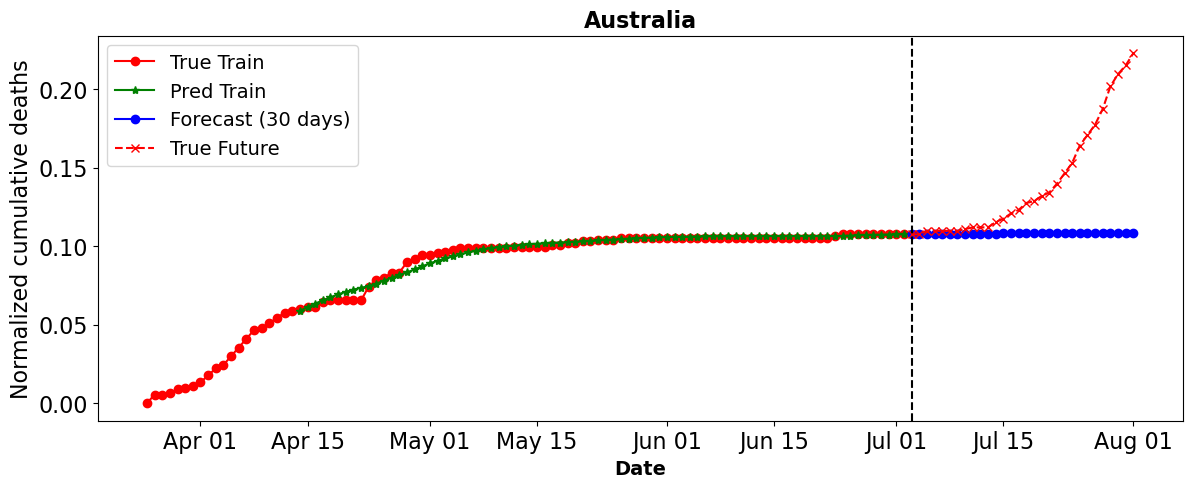

Australia — Forecast MSE: 0.002287


In [7]:

# Deaths-only Time-split Forecasting

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, r2_score

# Parameters
TRAIN_DAYS = 100
FORECAST_DAYS = 30
country_name  = "Australia"

# ---- extract one country
g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
true_seq = g['cumulative_norm'].values

# Split into train and test parts
train_seq = true_seq[:TRAIN_DAYS]
future_seq = true_seq[TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS]

# ---- Train on sliding windows inside training set
def create_windows(series, input_len=20, horizon=1):
    X, y = [], []
    for i in range(len(series) - input_len - horizon + 1):
        X.append(series[i:i+input_len])
        y.append(series[i+input_len:i+input_len+horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

INPUT_LEN = 20
HORIZON = 1  # one-step autoregressive
X_train, y_train = create_windows(train_seq, input_len=INPUT_LEN, horizon=HORIZON)

X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)

# ---- Model (LSTM version)
class DeathsLSTM(nn.Module):
    def __init__(self, input_len, hidden_dim=128, horizon=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, horizon)
        self.input_len = input_len

    def forward(self, x):
        # x: [B, input_len]
        x = x.unsqueeze(-1)  # [B, input_len, 1]
        out, _ = self.lstm(x)  # [B, input_len, hidden]
        h_last = out[:, -1, :]  # last hidden
        return self.fc(h_last)

model = DeathsLSTM(INPUT_LEN, hidden_dim=128, horizon=HORIZON)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

# ---- Train
for ep in range(2000):
    model.train()
    opt.zero_grad()
    



    pred = model(X_train_t).squeeze()
    loss = loss_fn(pred, y_train_t.squeeze())
    loss.backward()
    opt.step()
    if (ep+1) % 50 == 0:
        print(f"Epoch {ep+1} - Train Loss: {loss.item():.6f}")

# ---- Predict on train set
model.eval()
with torch.no_grad():
    pred_train = []
    for i in range(len(X_train_t)):
        pr = model(X_train_t[i].unsqueeze(0)).squeeze().item()
        pred_train.append(pr)

# ---- Forecast 30 days autoregressively
forecast = list(train_seq[-INPUT_LEN:])  # start with last input_len points
pred_future = []
with torch.no_grad():
    for _ in range(FORECAST_DAYS):
        x_in = torch.tensor(forecast[-INPUT_LEN:], dtype=torch.float32).unsqueeze(0)
        pr = model(x_in).squeeze().item()
        forecast.append(pr)
        pred_future.append(pr)

# ---- Plot
plt.figure(figsize=(14,5))
#g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)
#g['Date'] = pd.to_datetime(g['Date'])

# Train true
plt.plot(g['Date'][:TRAIN_DAYS], train_seq, 'ro-', label="True Train")
# Train pred (align with shifted points)

plt.plot(g['Date'][INPUT_LEN:TRAIN_DAYS], pred_train, 'g*-', label="Pred Train")
# Forecast (blue, after train)
plt.plot(g ['Date'][TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS], pred_future, 'bo-', label="Forecast (30 days)")
# True future
plt.plot(g['Date'][TRAIN_DAYS:TRAIN_DAYS+FORECAST_DAYS], future_seq, 'rx--', label="True Future")

plt.axvline(g['Date'].iloc[TRAIN_DAYS], color="k", linestyle="--")  # split line
plt.title(country_name ,fontsize=16 ,fontweight='bold')
plt.ylabel("Normalized cumulative deaths",fontsize = 16) #fontweight="bold"
plt.xlabel('Date', fontsize=14 ,fontweight='bold')
plt.legend(fontsize = 14)
plt.grid(False)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

ax.tick_params(axis='x', labelsize=16)
ax.tick_params(axis='y', labelsize=16)

#results_df.to_csv(f"{country_name}_deaths_forecast.csv", index=False)

print("File saved:", f"{country_name}_deaths_forecast.csv")

plt.show()

# ---- Metrics on forecast
mse = mean_squared_error(future_seq, pred_future)
r2 = r2_score(future_seq, pred_future)
print(f"{country_name} — Forecast MSE: {mse:.6f}" )


In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# ---- Align true train values
true_train_targets = train_seq[INPUT_LEN:TRAIN_DAYS]

# Convert to numpy
pred_train = np.array(pred_train)

# ---- Train metrics
train_mse = mean_squared_error(true_train_targets, pred_train)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(true_train_targets, pred_train)

print(f"{country_name} — Train MSE:  {train_mse:.6f}")
print(f"{country_name} — Train RMSE: {train_rmse:.6f}")
print(f"{country_name} — Train MAE:  {train_mae:.6f}")


Australia — Train MSE:  0.000008
Australia — Train RMSE: 0.002771
Australia — Train MAE:  0.001829
